# Supplementary Fig. 28 — performance of the longitudinal *phased* mCA caller (simulated test data)

Eight-panel evaluation of the TETRIS-seq **longitudinal phased** mCA caller against the simulated test set,
using an **index-sample cell fraction of 75%** and events **≥5 Mb** (n = 580 per target cell fraction).
Phasing is derived from the index sample and applied to lower-cell-fraction 'earlier timepoints' from the same
simulated individual; significance is a one-sided t-test (α = 0.05). 

- **a** overall sensitivity vs cell fraction · **b** by mCA type · **c** by event size · **d** by geometry
- **e** chromosome × cell-fraction heatmap · **f** cell-fraction estimation accuracy (median ± IQR)
- **g** phased vs unphased sensitivity per event type (shaded = gain from phasing)
- **h** effect of index-sample cell fraction (25 / 50 / 75 / 100%)


## Data availability
Self-contained: two **simulated** per-event outcome tables (no individual-level data) under
`Data_files/mCA_calling/Simulated_data/mCA_simulation_test_set/` — `sensitivity_results_all_ref_cfs.csv` (phased caller across index CFs)
and `truth_comparison.csv` (unphased outcomes, for panel g).

## 1. Imports, colours, constants

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
c0 = (0.76, 0.76, 0.76)
c1 = (1.00, 0.18, 0.33); c2 = (1.00, 0.23, 0.19)
c3 = (1.00, 0.58, 0.00); c4 = (1.00, 0.80, 0.00)
c5 = (0.30, 0.85, 0.39); c6 = (0.35, 0.78, 0.98)
c7 = (0.20, 0.67, 0.86); c8 = (0.00, 0.48, 1.00)
c9 = (0.35, 0.34, 0.84); c10 = (0.00, 0.31, 0.57)

orange1='#feedde'; orange2='#fdbe85'; orange3='#fd8d3c'; orange4='#e6550d'; orange5='#a63603'
blue1='#eff3ff'; blue2='#bdd7e7'; blue3='#6baed6'; blue4='#3182bd'; blue5='#08519c'
green1='#edf8e9'; green2='#bae4b3'; green3='#74c476'; green4='#31a354'; green5='#006d2c'
grey1='#f7f7f7'; grey2='#cccccc'; grey3='#969696'; grey4='#636363'; grey5='#252525'
purple1='#f2f0f7'; purple2='#cbc9e2'; purple3='#9e9ac8'; purple4='#756bb1'; purple5='#54278f'
red1='#fee5d9'; red2='#fcae91'; red3='#fb6a4a'; red4='#de2d26'; red5='#a50f15'

In [3]:
CHROM_ORDER = [f'chr{i}' for i in range(1, 23)] + ['chrX']
CHROM_LABELS = [str(i) for i in range(1, 23)] + ['X']

# Size categories
ALL_SIZES = ['2Mb', '3Mb', '5Mb', '10Mb', '20Mb', 'WholeArm']
SIZES_5PLUS = ['5Mb', '10Mb', '20Mb', 'WholeArm']

# Shared styling
EVENT_COLORS = {'CN-LOH': '#2E86AB', 'GAIN': '#F77F00', 'LOSS': '#06A77D'}
SIZE_COLORS = {
    '2Mb': '#E63946', '3Mb': '#F77F00', '5Mb': '#FCBF49',
    '10Mb': '#06A77D', '20Mb': '#2E86AB', 'WholeArm': '#7B2D8E'
}
GEOM_COLORS = {'Interstitial': '#2E86AB', 'Telomeric': '#F77F00', 'Whole_Arm': '#06A77D'}


REF_CF_COLORS = {1.0: blue5, 0.75: blue3, 0.5: orange3, 0.25: red4}
REF_CF_MARKERS = {1.0: 's', 0.75: 'D', 0.5: '^', 0.25: 'o'}

## 2. Helper functions (metrics + data loaders)

In [4]:
def sensitivity_by_group(df, group_col, cf_col='cf_true', sig_col='significant_raw'):
    """Compute sensitivity for each group × CF combination."""
    result = {}
    for grp in sorted(df[group_col].unique()):
        grp_df = df[df[group_col] == grp]
        sens = {}
        for cf in sorted(grp_df[cf_col].unique()):
            subset = grp_df[grp_df[cf_col] == cf]
            n = len(subset)
            n_sig = int(subset[sig_col].sum())
            sens[cf] = {'pct': n_sig / n * 100 if n > 0 else 0, 'det': n_sig, 'n': n}
        result[grp] = sens
    return result

In [5]:
def find_50pct_threshold(sens_dict):
    """Find CF (as %) at which sensitivity first reaches 50%."""
    for cf in sorted(sens_dict.keys()):
        if sens_dict[cf]['pct'] >= 50:
            return cf * 100
    return None

In [6]:
def load_unphased_sensitivity(csv_path):
    """Load unphased results and compute sensitivity by event and size."""
    tc = pd.read_csv(csv_path)
    event_map = {'CNLOH': 'CN-LOH', 'GAIN': 'GAIN', 'LOSS': 'LOSS'}
    tc['event'] = tc['Truth_Type'].map(event_map)
    tc['size_cat'] = pd.cut(
        tc['Truth_Length_Mb'],
        bins=[0, 2.5, 3.5, 5.5, 10.5, 20.5, 200],
        labels=['2Mb', '3Mb', '5Mb', '10Mb', '20Mb', 'WholeArm']
    )

    by_event = {}
    for evt in ['CN-LOH', 'GAIN', 'LOSS']:
        evt_df = tc[tc['event'] == evt]
        sens = {}
        for cf in sorted(evt_df['Truth_Fraction'].unique()):
            subset = evt_df[evt_df['Truth_Fraction'] == cf]
            n = len(subset)
            n_tp = (subset['Status'] == 'TRUE_POSITIVE').sum()
            sens[cf] = n_tp / n * 100 if n > 0 else 0
        by_event[evt] = sens

    by_size = {}
    for size in ALL_SIZES:
        size_df = tc[tc['size_cat'] == size]
        sens = {}
        for cf in sorted(size_df['Truth_Fraction'].unique()):
            subset = size_df[size_df['Truth_Fraction'] == cf]
            n = len(subset)
            n_tp = (subset['Status'] == 'TRUE_POSITIVE').sum()
            sens[cf] = n_tp / n * 100 if n > 0 else 0
        by_size[size] = sens

    return by_event, by_size

In [7]:
def load_and_normalise(csv_path, longitudinal=False, ref_cf=None):
    """
    Load a phased results CSV and normalise columns so all plotting
    functions can use the same column names:
        cf_true, significant_raw, event, size, chromosome, cf_estimate, geometry

    Parameters
    ----------
    csv_path : str - path to CSV
    longitudinal : bool - if True, treat as longitudinal pipeline output
    ref_cf : float or None - for longitudinal data, filter to this reference CF
    """
    df = pd.read_csv(csv_path)

    if longitudinal:
        # Filter to tested rows only
        if 'status' in df.columns:
            df = df[df['status'] == 'tested'].copy()

        # Filter to requested reference CF
        if ref_cf is not None and 'ref_cf' in df.columns:
            df = df[np.isclose(df['ref_cf'], ref_cf)].copy()

        # Rename columns to match per-sample format
        rename_map = {}
        if 'target_cf' in df.columns and 'cf_true' not in df.columns:
            rename_map['target_cf'] = 'cf_true'
        if 'significant' in df.columns and 'significant_raw' not in df.columns:
            rename_map['significant'] = 'significant_raw'
        if 'n_hets' in df.columns and 'n_hets_inside' not in df.columns:
            rename_map['n_hets'] = 'n_hets_inside'
        if rename_map:
            df = df.rename(columns=rename_map)

    # Ensure required columns exist
    required = ['cf_true', 'significant_raw', 'event', 'size', 'chromosome']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns after normalisation: {missing}")

    return df

## 3. Load the simulated phased test-set results (index CF = 75%)

In [8]:
# Simulated TEST-set results for the longitudinal PHASED caller (no individual-level data).
# sensitivity_results_all_ref_cfs.csv: one row per (control, event, target cell fraction, index/ref CF).
DATA = 'Data_files/mCA_calling/Simulated_data/mCA_simulation_test_set/'
LONG_CSV     = DATA + 'sensitivity_results_all_ref_cfs.csv'
UNPHASED_CSV = DATA + 'truth_comparison.csv'   # unphased outcomes, for the panel-g comparison

REF_CF = 0.75   # index-sample cell fraction used for the main panels (a-g)
df_long = load_and_normalise(LONG_CSV, longitudinal=True, ref_cf=REF_CF)
df_long_5plus = df_long[df_long['size'].isin(SIZES_5PLUS)]
unphased_by_event, unphased_by_size = load_unphased_sensitivity(UNPHASED_CSV)
print(f'index={REF_CF:.0%}: {len(df_long)} events ({len(df_long_5plus)} >=5Mb), '
      f'n per target CF = {len(df_long[df_long["cf_true"]==0.5])}')

index=75%: 6960 events (6204 >=5Mb), n per target CF = 580


## 4. Panels a–f — six-panel sensitivity analysis (≥5 Mb)

In [9]:
def plot_sensitivity_6panel(df, title_suffix, output_name, fpr_df=None, ref_cf=None):
    """
    Layout (mirrors unphased figure):
      Row 1 (4 panels): Size | Overall | Event Type | Geometry
      Row 2 (2 panels): CF Estimation Accuracy | Chromosome × CF heatmap
    """
    fig = plt.figure(figsize=(26, 12))
    fig.suptitle(f'Phased Detection: Sensitivity Analysis ({title_suffix})',
                 fontsize=16, fontweight='bold', y=0.98)

    gs_top = fig.add_gridspec(1, 4, left=0.05, right=0.98, top=0.88, bottom=0.54,
                               wspace=0.35)
    gs_bot = fig.add_gridspec(1, 2, left=0.05, right=0.98, top=0.46, bottom=0.12,
                               wspace=0.35, width_ratios=[1.12, 3.7])

    ax_size  = fig.add_subplot(gs_top[0])
    ax_over  = fig.add_subplot(gs_top[1])
    ax_evt   = fig.add_subplot(gs_top[2])
    ax_geom  = fig.add_subplot(gs_top[3])
    ax_cf    = fig.add_subplot(gs_bot[0])
    ax_heat  = fig.add_subplot(gs_bot[1])

    cf_values = sorted(df['cf_true'].unique())

    def fmt_log_axis(ax):
        ax.set_xscale('log')
        ax.set_xticks([0.1, 0.5, 1, 5, 10, 50, 100])
        ax.get_xaxis().set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'{x:g}'))
        ax.set_xlim(0.08, 130)

    # ── Panel a: Sensitivity by Event Size ──
    size_sens = sensitivity_by_group(df, 'size')
    size_order = [s for s in ALL_SIZES if s in size_sens]
    for size in size_order:
        cfs = sorted(size_sens[size].keys())
        ax_size.plot([c * 100 for c in cfs], [size_sens[size][c]['pct'] for c in cfs],
                     'o-', color=SIZE_COLORS.get(size, 'grey'), linewidth=2.5, markersize=8, label=size)
    ax_size.axhline(50, color='grey', linestyle='--', alpha=0.5)
    ax_size.legend(fontsize=9, loc='lower right', title='Event Size', title_fontsize=9)
    ax_size.set_xlabel('Cell Fraction (%)', fontsize=11)
    ax_size.set_ylabel('Sensitivity (%)', fontsize=11)
    ax_size.set_title('Sensitivity by Event Size', fontsize=12, fontweight='bold')
    fmt_log_axis(ax_size)
    ax_size.set_ylim(-2, 105)
    ax_size.grid(alpha=0.2, which="both")

    # ── Panel b: Overall Sensitivity ──
    event_sens = sensitivity_by_group(df, 'event')
    stats = []
    for cf in cf_values:
        subset = df[df['cf_true'] == cf]
        n = len(subset)
        det = int(subset['significant_raw'].sum())
        stats.append((cf * 100, det / n * 100 if n > 0 else 0, det, n))
    ax_over.plot([s[0] for s in stats], [s[1] for s in stats],
                 'o-', color='#2166AC', linewidth=2.5, markersize=9, zorder=3)
    for cp, s, d, n in stats:
        if s > 0 or cp >= 1:
            ax_over.annotate(f'{d}/{n}', (cp, s), textcoords='offset points',
                             xytext=(0, 12), fontsize=7, ha='center', fontweight='bold')
    ax_over.axhline(50, color='grey', linestyle='--', alpha=0.5)
    ax_over.set_xlabel('Cell Fraction (%)', fontsize=11)
    ax_over.set_ylabel('Sensitivity (%)', fontsize=11)
    ax_over.set_title('Overall Sensitivity vs Cell Fraction', fontsize=12, fontweight='bold')
    fmt_log_axis(ax_over)
    ax_over.set_ylim(-2, 105)
    ax_over.grid(alpha=0.2, which="both")
    ax_over.text(0.02, 0.95, '50% sensitivity', transform=ax_over.transAxes,
                 fontsize=9, color='grey', va='top')

    # ── Panel c: Sensitivity by Event Type ──
    for evt in ['CN-LOH', 'GAIN', 'LOSS']:
        if evt not in event_sens:
            continue
        cfs = sorted(event_sens[evt].keys())
        ax_evt.plot([c * 100 for c in cfs], [event_sens[evt][c]['pct'] for c in cfs],
                    'o-', color=EVENT_COLORS[evt], linewidth=2.5, markersize=8, label=evt)
    ax_evt.axhline(50, color='grey', linestyle='--', alpha=0.5)
    ax_evt.legend(fontsize=10, loc='lower right')
    ax_evt.set_xlabel('Cell Fraction (%)', fontsize=11)
    ax_evt.set_ylabel('Sensitivity (%)', fontsize=11)
    ax_evt.set_title('Sensitivity by Event Type', fontsize=12, fontweight='bold')
    fmt_log_axis(ax_evt)
    ax_evt.set_ylim(-2, 105)
    ax_evt.grid(alpha=0.2, which="both")

    # ── Panel d: Sensitivity by Geometry ──
    geom_sens = sensitivity_by_group(df, 'geometry')
    for geom in ['Interstitial', 'Telomeric', 'Whole_Arm']:
        if geom not in geom_sens:
            continue
        cfs = sorted(geom_sens[geom].keys())
        ax_geom.plot([c * 100 for c in cfs], [geom_sens[geom][c]['pct'] for c in cfs],
                     'o-', color=GEOM_COLORS.get(geom, 'grey'), linewidth=2.5, markersize=8, label=geom)
    ax_geom.axhline(50, color='grey', linestyle='--', alpha=0.5)
    ax_geom.legend(fontsize=10, loc='lower right')
    ax_geom.set_xlabel('Cell Fraction (%)', fontsize=11)
    ax_geom.set_ylabel('Sensitivity (%)', fontsize=11)
    ax_geom.set_title('Sensitivity by Geometry', fontsize=12, fontweight='bold')
    fmt_log_axis(ax_geom)
    ax_geom.set_ylim(-2, 105)
    ax_geom.grid(alpha=0.2, which="both")

    # ── Panel e: CF Estimation Accuracy — median ± IQR, no scatter ──
    sig_df = df[df['significant_raw'] == True].copy()
    if len(sig_df) > 0:
        ax_cf.plot([0.05, 120], [0.05, 120], 'k--', linewidth=1, alpha=0.5, label='Perfect')
        for evt in ['CN-LOH', 'GAIN', 'LOSS']:
            evt_df = sig_df[sig_df['event'] == evt]
            if len(evt_df) > 0:
                grp   = evt_df.groupby('cf_true')['cf_estimate']
                med   = grp.median() * 100
                q25   = grp.quantile(0.25) * 100
                q75   = grp.quantile(0.75) * 100
                x_vals = med.index * 100
                ax_cf.plot(x_vals, med.values, 'o-',
                           color=EVENT_COLORS[evt], markersize=8, linewidth=2.5,
                           label=evt, alpha=0.95, zorder=5)
                ax_cf.fill_between(x_vals, q25.values, q75.values,
                                   color=EVENT_COLORS[evt], alpha=0.18, zorder=4)
    ax_cf.legend(fontsize=8, loc='upper left')
    ax_cf.set_xlabel('True Cell Fraction (%)', fontsize=11)
    ax_cf.set_ylabel('Estimated Cell Fraction (%)', fontsize=11)
    ax_cf.set_title('CF Estimation Accuracy (median ± IQR)', fontsize=12, fontweight='bold')
    ax_cf.set_xscale('log'); ax_cf.set_yscale('log')
    ax_cf.set_xticks([0.1, 0.5, 1, 5, 10, 50, 100])
    ax_cf.set_yticks([0.1, 0.5, 1, 5, 10, 50, 100])
    ax_cf.get_xaxis().set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
    ax_cf.get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
    ax_cf.set_xlim(0.05, 130); ax_cf.set_ylim(0.05, 130)
    ax_cf.grid(alpha=0.2, which='both')

    # ── Panel f: Sensitivity by chromosome × CF heatmap ──
    df_h = df.copy()
    df_h['chrom_clean'] = df_h['chromosome'].astype(str)
    if not df_h['chrom_clean'].str.startswith('chr').all():
        df_h['chrom_clean'] = 'chr' + df_h['chrom_clean'].str.replace('chr', '', regex=False)
    df_h = df_h[df_h['chrom_clean'].isin(CHROM_ORDER)]
    cf_heatmap = [cf for cf in sorted(df_h['cf_true'].unique()) if cf >= 0.005]
    cf_heatmap_labels = [f'{cf*100:g}%' for cf in cf_heatmap]

    matrix = np.zeros((len(cf_heatmap), len(CHROM_ORDER)))
    for j, chrom in enumerate(CHROM_ORDER):
        for i, cf in enumerate(cf_heatmap):
            subset = df_h[(df_h['chrom_clean'] == chrom) & (df_h['cf_true'] == cf)]
            n = len(subset)
            if n > 0:
                matrix[i, j] = subset['significant_raw'].sum() / n * 100

    # highest CF at top
    matrix_plot = matrix[::-1]
    cf_labels_plot = cf_heatmap_labels[::-1]

    im = ax_heat.imshow(matrix_plot, cmap='RdYlBu', vmin=0, vmax=100, aspect='auto')
    for i in range(len(cf_heatmap)):
        for j in range(len(CHROM_ORDER)):
            val = matrix_plot[i, j]
            color = 'white' if val < 25 or val > 85 else 'black'
            ax_heat.text(j, i, f'{val:.0f}', ha='center', va='center',
                         fontsize=7, fontweight='bold', color=color)
    ax_heat.set_xticks(range(len(CHROM_ORDER)))
    ax_heat.set_xticklabels(CHROM_LABELS, fontsize=9)
    ax_heat.set_xlabel('Chromosome', fontsize=11)
    ax_heat.set_yticks(range(len(cf_heatmap)))
    ax_heat.set_yticklabels(cf_labels_plot, fontsize=10)
    ax_heat.set_ylabel('Cell Fraction', fontsize=11)
    cf_threshold = 10
    ax_heat.set_title(f'Sensitivity by Chromosome and Cell Fraction (≥{cf_threshold}%)',
                      fontsize=12, fontweight='bold')
    fig.colorbar(im, ax=ax_heat, fraction=0.015, pad=0.02).set_label('Sensitivity (%)', fontsize=10)

    for ax in [ax_size, ax_over, ax_evt, ax_geom, ax_cf, ax_heat]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for axis in ['bottom', 'left']:
            ax.spines[axis].set_linewidth(1.5)
            ax.spines[axis].set_color(grey3)
        ax.xaxis.set_tick_params(width=1, color=grey3, length=6)
        ax.yaxis.set_tick_params(width=1, color=grey3, length=6)
    plt.show()

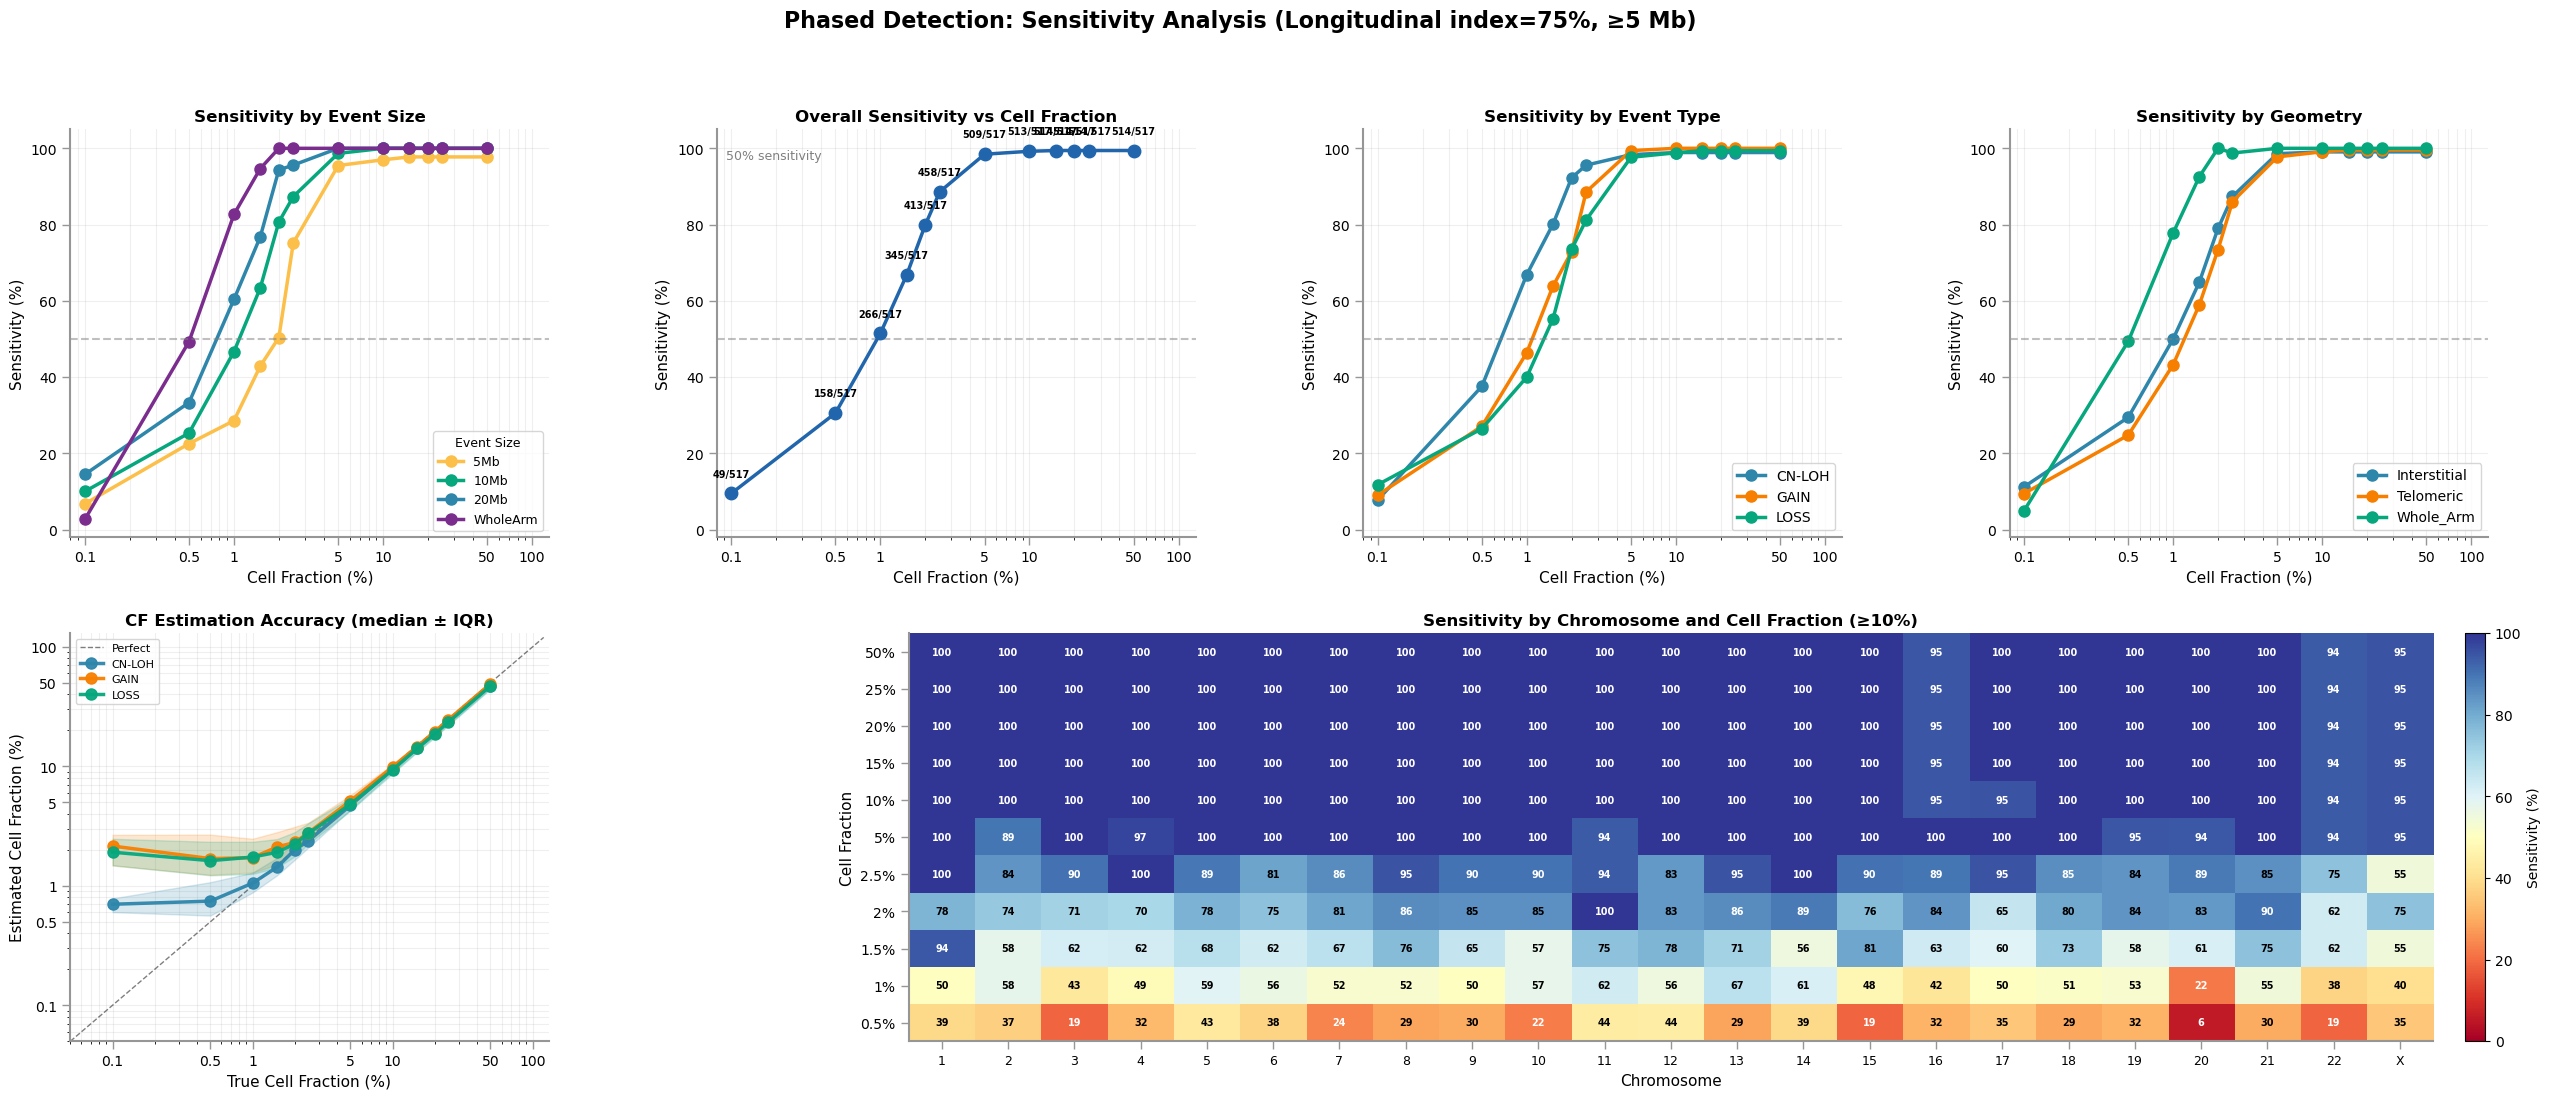

In [10]:
plot_sensitivity_6panel(df_long_5plus, 'Longitudinal index=75%, ≥5 Mb', 'suppfig28_af')

## 5. Panel g — phased vs unphased sensitivity by event type

In [11]:
def plot_comparison_curves(phased_df, unphased_by_event, phased_label='Phased (ground truth)'):
    """3-panel: unphased vs phased sensitivity by event type."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
    event_labels = {'CN-LOH': 'CN-LOH', 'GAIN': 'Gain', 'LOSS': 'Loss'}

    phased_sens = sensitivity_by_group(phased_df, 'event')

    for ax, evt in zip(axes, ['CN-LOH', 'GAIN', 'LOSS']):
        color = EVENT_COLORS[evt]

        # Unphased
        u_cfs = sorted(unphased_by_event[evt].keys())
        u_sens = [unphased_by_event[evt][cf] for cf in u_cfs]
        u_pct = [cf * 100 for cf in u_cfs]

        # Phased
        p_cfs = sorted(phased_sens[evt].keys())
        p_sens = [phased_sens[evt][cf]['pct'] for cf in p_cfs]
        p_pct = [cf * 100 for cf in p_cfs]

        # Fill between (common CFs)
        common = sorted(set(u_cfs) & set(p_cfs))
        common_pct = [cf * 100 for cf in common]
        ax.fill_between(common_pct,
                       [unphased_by_event[evt][cf] for cf in common],
                       [phased_sens[evt][cf]['pct'] for cf in common],
                       alpha=0.15, color=color)

        ax.plot(u_pct, u_sens, 'o-', color=color, alpha=0.4, linewidth=2, markersize=6, label='Unphased')
        ax.plot(p_pct, p_sens, 's-', color=color, linewidth=2.5, markersize=7, label=phased_label)
        ax.axhline(50, color='grey', linestyle=':', alpha=0.5)

        ax.set_title(event_labels[evt], fontsize=16, fontweight='bold', pad=10)
        ax.set_xlabel('Cell Fraction (%)', fontsize=12)
        if ax == axes[0]:
            ax.set_ylabel('Sensitivity (%)', fontsize=12)
        # ax.set_xlim(-1, 105); ax.set_ylim(-1, 105)
        # ax.set_xscale('symlog', linthresh=1)
        ax.set_xscale('log')
        ax.set_xticks([0.1, 0.5, 1, 5, 10, 25, 50, 100])
        ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
        ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for axis in ['bottom','left']:
            ax.spines[axis].set_linewidth(1.5)
            ax.spines[axis].set_color(grey3)
        ax.xaxis.set_tick_params(width=1, color = grey3, length = 6)
        ax.yaxis.set_tick_params(width=1, color = grey3, length = 6)

    fig.suptitle('Detection Sensitivity: Unphased vs Phased Analysis',
                 fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

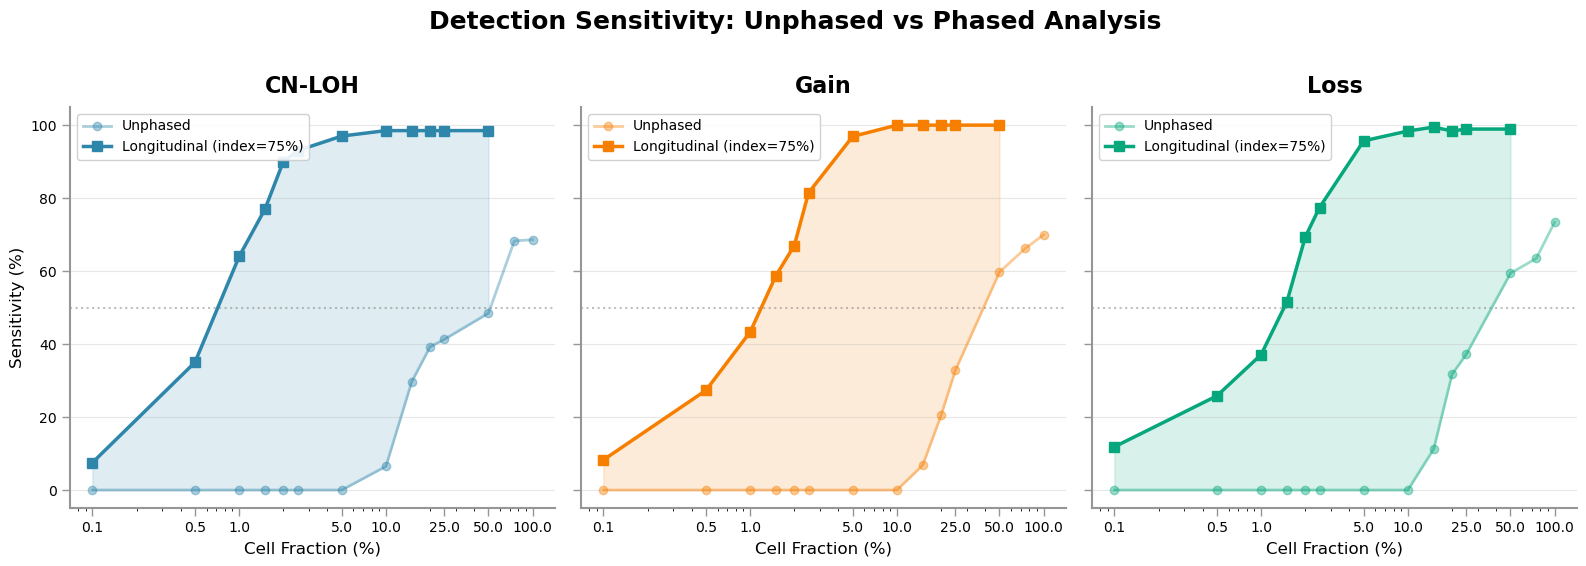

In [12]:
plot_comparison_curves(df_long, unphased_by_event, phased_label='Longitudinal (index=75%)')

## 6. Panel h — effect of index-sample cell fraction

In [13]:
def plot_longitudinal_ref_comparison_overall(ref_dfs):
    """Overall sensitivity curve for each reference CF, overlaid."""
    fig, ax = plt.subplots(figsize=(8, 5.5))

    for ref_cf, df in sorted(ref_dfs.items(), reverse=True):
        cf_values = sorted(df['cf_true'].unique())
        sens = []
        for cf in cf_values:
            subset = df[df['cf_true'] == cf]
            n = len(subset)
            det = int(subset['significant_raw'].sum())
            sens.append(det / n * 100 if n > 0 else 0)

        label = f'index={ref_cf*100:.0f}% (N={len(df[df["cf_true"]==cf_values[0]])})'
        ax.plot([c * 100 for c in cf_values], sens,
                marker=REF_CF_MARKERS.get(ref_cf, 'o'), linestyle='-',
                color=REF_CF_COLORS.get(ref_cf, 'grey'),
                linewidth=2, markersize=6, label=label)

    ax.axhline(50, color='grey', linestyle='--', alpha=0.5)
    ax.set_xlabel('Target Cell Fraction (%)', fontsize=12)
    ax.set_ylabel('Sensitivity (%)', fontsize=12)
    ax.set_title('Longitudinal Detection: Effect of Index Sample Cell Fraction',
                 fontsize=14, fontweight='bold')
    ax.set_xscale('log')
    ax.set_xticks([0.1, 0.5, 1, 2.5, 5, 10, 25, 50, 75])
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.set_ylim(-2, 105)
    ax.legend(fontsize=10, loc='lower right')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey3)
    ax.xaxis.set_tick_params(width=1, color=grey3, length=6)
    ax.yaxis.set_tick_params(width=1, color=grey3, length=6)
    ax.grid(axis='y', alpha=0.2)

    plt.tight_layout()
    plt.show()

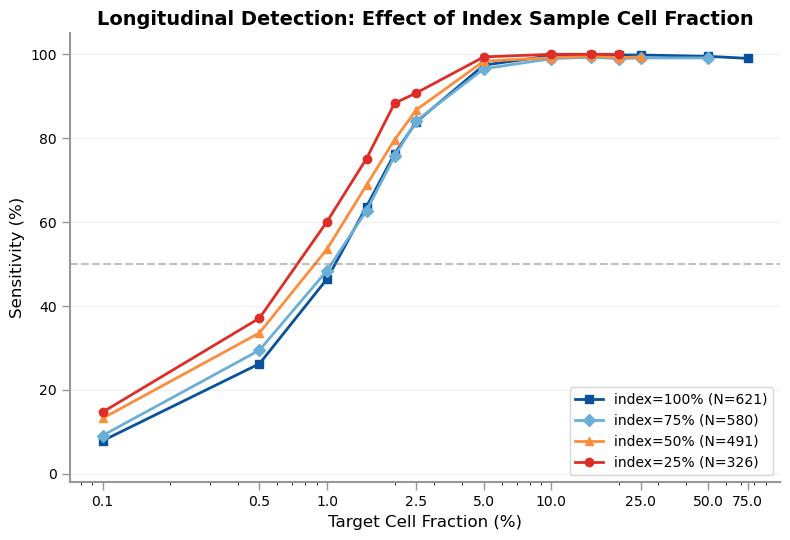

In [14]:
# Panel h loads the longitudinal results at each index (reference) cell fraction.
ref_dfs = {}
for rcf in [1.0, 0.75, 0.5, 0.25]:
    rdf = load_and_normalise(LONG_CSV, longitudinal=True, ref_cf=rcf)
    if len(rdf) > 0:
        ref_dfs[rcf] = rdf
plot_longitudinal_ref_comparison_overall(ref_dfs)